# Topic Modeling

BERTopic is used for topic modeling to divide OpenAlex's papers into several topics in preparation for subsequent experiments.

Models that need to be prepared in advance:

1. **Large Language Model for topic interpretation**, in GGUF format. This experiment uses Qwen2.5-14B-Instruct-Q8_0. This model should be placed in the `./llm/gguf` path of the working directory. Download link: https://huggingface.co/Qwen/Qwen2.5-14B-Instruct-GGUF/tree/main
2. **Embedding Model**. This experiment uses the bge-small-en model from BAAI. This model should be placed in the `./llm/bge-small-en` path of the working directory. Download link: https://huggingface.co/BAAI/bge-small-en/tree/main

Data that need to be prepared in advance:

**The list of papers** and organize them in OpenAlex's JSON format, with one paper per line. The data used in this experiment is filtered according to the AI ​​category of the CSRanking recommended conference list. The data should be a single txt file and placed in the `./openalex-data` folder.

## Environment Configuration

In [1]:
# conda create -n cet python=3.11
# conda activate cet
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# pip install llama-cpp-python==0.3.4 --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu122
# pip install cudf-cu12 dask-cudf-cu12 cuml-cu12 cugraph-cu12 --extra-index-url=https://pypi.nvidia.com
# pip install bertopic datasets matplotlib

Set which cards to use to run the model.

This experiment was completed based on 2 \* RTX4090 24G.

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "4,5"

from bertopic.representation import KeyBERTInspired, LlamaCPP
from llama_cpp import Llama
import json
from sentence_transformers import SentenceTransformer
from cuml.manifold import UMAP
from cuml.cluster import HDBSCAN
from bertopic import BERTopic
import re
import matplotlib.pyplot as plt

/home/user/.conda/envs/cet/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Import the LLM for topic representation using llama.cpp.

In [2]:
def define_representation_model() -> dict:
    """Import the LLM for topic representation."""
    llm = Llama(
        model_path="./llm/gguf/qwen2.5-14b-instruct-q8_0-00001-of-00004.gguf",
        n_gpu_layers=-1,
        n_ctx=32768,
        stop=["Q:", "\n"],
        verbose=False,
        seed=1,
    )

    prompt = """ Q:
    I have a topic that contains the following documents:
    [DOCUMENTS]

    The topic is described by the following keywords: '[KEYWORDS]'.

    Based on the above information, can you give a short label of the topic of at most 5 words?
    A:
    """

    representation_model = {
        "KeyBERT": KeyBERTInspired(),
        "LLM": LlamaCPP(llm, prompt=prompt),
    }
    return representation_model


MODEL_REPRESENTATION = define_representation_model()

llama_new_context_with_model: n_ctx_per_seq (32768) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


Import the data. Note that OpenAlex's summary is not stored as a string and needs to be converted by yourself.

In [ ]:
def inverted_index_to_abstract(paper_json: dict) -> None:
    """Turn inverted index in json into raw abstract.

    Args:
        paper_json (dict): json in each line of works.txt in OpenAlex dataset.
    """
    inverted_index = paper_json["abstract_inverted_index"]
    # Deal with works like https://openalex.org/W4247653807
    if (
        inverted_index is None
        or inverted_index == {}
        or len(paper_json["authorships"]) == 0
    ):
        paper_json["abstract"] = None
        return
    max_index = max(
        index for word_index in inverted_index.values() for index in word_index
    )
    sentence_list = [""] * (max_index + 1)
    for word, word_index in inverted_index.items():
        for index in word_index:
            sentence_list[index] = word
    paper_abstract = " ".join(sentence_list)
    if paper_abstract == "No abstract available.":
        paper_json["abstract"] = None
        return
    if paper_abstract == "No disponible":
        paper_json["abstract"] = None
        return
    if paper_abstract.startswith("An abstract is not available for this content"):
        paper_json["abstract"] = None
        return
    paper_json["abstract"] = paper_abstract


def import_data(filename: str) -> dict:
    all_papers_dict = {}
    with open(filename, "r", encoding="utf-8") as f:
        for line in f:
            paper_json = json.loads(line)
            inverted_index_to_abstract(paper_json)
            if paper_json["abstract"] is None:
                continue
            all_papers_dict[paper_json["id"]] = paper_json
    return all_papers_dict


DATASET = "./openalex_data/csr-ai-works.txt"
# DATASET = "./openalex_data/ccf-ai-works.txt"
# DATASET = "./openalex_data/lis-works.txt"
# DATASET = "./openalex_data/soci-works.txt"
# DATASET = "./openalex_data/ccfa-works.txt"
DATA_PAPER = import_data(DATASET)
len(DATA_PAPER)

171428

The same index of `DATA_*` represents the same paper.

In [5]:
DATA_ID = [paper["id"] for paper in DATA_PAPER.values()]
DATA_ABSTRACT = [DATA_PAPER[id]["abstract"] for id in DATA_ID]
DATA_YEAR = [DATA_PAPER[id]["publication_year"] for id in DATA_ID]

In [ ]:
# Pre-calculate embeddings
MODEL_EMBEDDING = SentenceTransformer("./llm/bge-small-en")
DATA_EMBEDDING = MODEL_EMBEDDING.encode(DATA_ABSTRACT, show_progress_bar=True)


Batches: 100%|██████████| 5358/5358 [02:58<00:00, 29.94it/s]


[2025-07-16 09:38:43.789] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-07-16 09:38:43.791] [CUML] [info] build_algo set to brute_force_knn because random_state is given


In [14]:
# Define sub-models
MODEL_UMAP = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=1,
)
MODEL_HDBSCAN = HDBSCAN(
    min_cluster_size=20,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
    random_state=1,
)

# Pre-reduce embeddings for visualization purposes
DATA_EMBEDDING_REDUCED = UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.0,
    metric="cosine",
    random_state=1,
).fit_transform(DATA_EMBEDDING)

[2025-07-16 09:43:26.693] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-07-16 09:43:26.694] [CUML] [info] Unused keyword parameter: random_state during cuML estimator initialization
[2025-07-16 09:43:26.694] [CUML] [info] build_algo set to brute_force_knn because random_state is given


Use BERTopic for topic modeling.

In [15]:
MODEL_TOPIC = BERTopic(
    # Sub-models
    embedding_model=MODEL_EMBEDDING,
    umap_model=MODEL_UMAP,
    hdbscan_model=MODEL_HDBSCAN,
    representation_model=MODEL_REPRESENTATION,
    # Hyperparameters
    top_n_words=10,
    verbose=True,
)

# Train model
topics, probs = MODEL_TOPIC.fit_transform(DATA_ABSTRACT, DATA_EMBEDDING)

# Create a label for each document
llm_labels = [re.sub(r'\W+', ' ', label[0][0].split("\n")[0].replace('"', '')) for label in MODEL_TOPIC.get_topics(full=True)["LLM"].values()]
DATA_LABEL_TYPE = [label if label else "Unlabelled" for label in llm_labels]
DATA_LABEL = [DATA_LABEL_TYPE[topic+MODEL_TOPIC._outliers] if topic != -1 else "Unlabelled" for topic in topics]

# Show topics
MODEL_TOPIC.get_topic_info()

2025-07-16 09:43:30,533 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-07-16 09:43:32,918 - BERTopic - Dimensionality - Completed ✓
2025-07-16 09:43:32,927 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-07-16 09:43:37,408 - BERTopic - Cluster - Completed ✓
2025-07-16 09:43:37,436 - BERTopic - Representation - Fine-tuning topics using representation models.
100%|██████████| 347/347 [01:44<00:00,  3.34it/s]
2025-07-16 09:46:02,971 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,KeyBERT,LLM,Representative_Docs
0,-1,115892,-1_the_and_of_to,"[the, and, of, to, in, we, for, is, that, this]","[algorithm, models, model, network, results, l...",[Computer Vision and Machine Learning Algorith...,[Human visual perception is able to recognize ...
1,0,3502,0_alert_citation_profile_university,"[alert, citation, profile, university, your, a...","[citationpublisher, article, acm, cited, resea...","[Graph Algorithms and Citations, , , , , , , ,...",[Article A parallel algorithm for the maximal ...
2,1,2977,1_software_code_developers_development,"[software, code, developers, development, test...","[refactoring, debugging, research, developers,...","[Software Development and Testing Techniques, ...",[What are software developers doing during a c...
3,2,2469,2_virtual_vr_reality_ar,"[virtual, vr, reality, ar, haptic, immersive, ...","[vr, immersive, virtual, hmds, haptics, resear...","[Virtual Reality Usability Challenges, , , , ,...",[Work space simulations help trainees acquire ...
4,3,2412,3_search_retrieval_document_documents,"[search, retrieval, document, documents, query...","[relevance, retrieval, clustering, semantic, r...","[Entity Aspect Search Enhancements, , , , , , ...","[Recently, significant progress has been made ..."
...,...,...,...,...,...,...,...
342,341,20,341_web_revisitation_bookmarks_page,"[web, revisitation, bookmarks, page, scrollbar...","[pagelinker, revisitation, bookmarks, bookmark...","[Web Page Revisitation Techniques, , , , , , ,...",[One problem web users often face is that of r...
343,342,20,342_fourier_sparse_signal_fft,"[fourier, sparse, signal, fft, recovery, trans...","[sparse, fourier, sparsity, fft, interpolation...","[Sparse Fourier Transform Algorithms, , , , , ...",[The problem of approximately computing the k ...
344,343,20,343_wearable_wearables_smart_tennis,"[wearable, wearables, smart, tennis, emotive, ...","[wearables, wearable, wearability, technology,...","[Wearable Technology and Trends, , , , , , , ,...",[Personalized wearable ICT systems presented i...
345,344,20,344_illumination_reflectance_chromaticity_cons...,"[illumination, reflectance, chromaticity, cons...","[chromaticities, chromaticity, illuminants, re...","[Color Constancy and Illumination Effects, , ,...",[Existing color constancy methods cannot handl...


Visualize the distribution of papers after embedding.

(171428, 2)


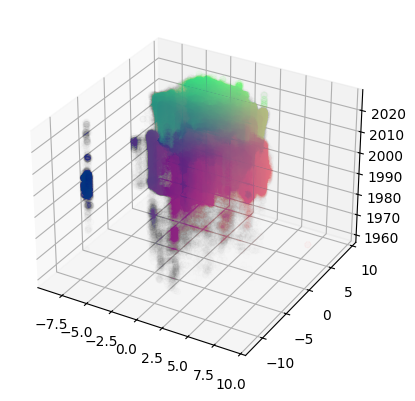

In [16]:
def plot_embedding_with_year(reduced_embeddings, years, alpha) -> None:
    plt.figure()
    ax = plt.axes(projection="3d")

    x = reduced_embeddings[:, 0]
    y = reduced_embeddings[:, 1]
    for i, xi in enumerate(x):
        if xi < -20 or xi > 20:
            print(DATA_ID[i], DATA_ABSTRACT[i])
    cx = (x - min(x)) / (max(x) - min(x))
    cy = (y - min(y)) / (max(y) - min(y))
    z = years
    c = [[xi, yi, 0.5] for xi, yi in zip(cx, cy)]

    ax.scatter(x, y, z, c=c, alpha=alpha)
    plt.show()
    plt.close()

print(DATA_EMBEDDING_REDUCED.shape)
plot_embedding_with_year(DATA_EMBEDDING_REDUCED, DATA_YEAR, 0.002)

In [ ]:
output_dir = "./topics_new/"

if not os.path.exists(output_dir):
    os.mkdir(output_dir)

for i, topic_name in enumerate(DATA_LABEL_TYPE):
    if i == 0:
        continue
    topic_id = [id for i, id in enumerate(DATA_ID) if DATA_LABEL[i] == topic_name]
    topic_year = [DATA_PAPER[id]["publication_year"] for id in topic_id]
    topic_keyword = [DATA_PAPER[id]["keywords"] for id in topic_id]
    data = {
        "topic_name": topic_name,
        "topic_id": topic_id,
        "topic_year": topic_year,
        "topic_keyword": topic_keyword,
    }
    with open(os.path.join(output_dir, f"{i}.txt"), "w", encoding="utf-8") as f:
        json.dump(data, f)